<a href="https://colab.research.google.com/github/Inderjeet-singh01/Shine-Dezign/blob/main/Height_to_Weight_Estimator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Height-to-Weight Estimator**



*   **Predictive Accuracy:**  Developed a Linear Regression model to accurately estimate body weight based on height inputs.

*   **User Input Feature:**  Includes a simple function where users can enter any height value to get an immediate weight prediction.
*   **Data Analysis:** Performed Exploratory Data Analysis (EDA) to understand the correlation between physical metrics and handled outliers for better model stability.


*   **Mathematical Precision:**  Optimized the model by minimizing the Mean Squared Error (MSE) and achieving a strong R-squared score.



In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ML/Weight Prediction/HeightWeight.csv")
df.tail()

,Index,Height(Inches),Weight(Pounds)
24995,24996,69.50215,118.0312
24996,24997,64.54826,120.1932
24997,24998,64.69855,118.2655
24998,24999,67.52918,132.2682
24999,25000,68.87761,124.8742


In [7]:
df.isnull().sum()

,0
Index,0
Height(Inches),0
Weight(Pounds),0


In [8]:
# Converting Units

df["Height(Feet)"] = df["Height(Inches)"] / 12       #Inches to Feet
df["Weight(Kg)"] = df["Weight(Pounds)"] * 0.453592   #Pounds to kg
df.drop(["Height(Inches)", "Index", "Weight(Pounds)"], axis=1, inplace=True)  #Remove extra features

df.tail()

,Height(Feet),Weight(Kg)
24995,5.791846,53.538008
24996,5.379022,54.518674
24997,5.391546,53.644285
24998,5.627432,59.995797
24999,5.739801,56.641938


In [9]:
#Creating Independent & Dependent Features

x= df[['Height(Feet)']]
y= df['Weight(Kg)']

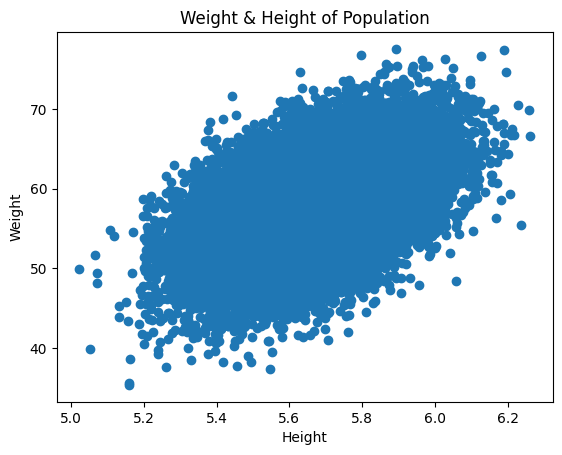

In [10]:
# Data Visualization
plt.scatter(x, y)
plt.xlabel("Height")
plt.ylabel("Weight")
plt.title("Weight & Height of Population")
plt.show()

In [11]:
## Scaling i/p value between 0-1

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
x = scaler.fit_transform(x)
x,y

(array([[0.37009461],
        [0.75544693],
        [0.61315787],
        ...,
        [0.29716682],
        [0.48746844],
        [0.5781226 ]]),
 0        51.252494
 1        61.909547
 2        69.411778
 3        64.562199
 4        65.452010
            ...    
 24995    53.538008
 24996    54.518674
 24997    53.644285
 24998    59.995797
 24999    56.641938
 Name: Weight(Kg), Length: 25000, dtype: float64)

In [12]:
df

,Height(Feet),Weight(Kg)
0,5.481942,51.252494
1,5.959601,61.909547
2,5.783228,69.411778
3,5.684717,64.562199
4,5.648984,65.452010
...,...,...
24995,5.791846,53.538008
24996,5.379022,54.518674
24997,5.391546,53.644285
24998,5.627432,59.995797


In [13]:
#Train Test Split

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test= train_test_split(x,y, test_size=0.2)
print(x_train.shape)
print(x_test.shape)

(20000, 1)
(5000, 1)


In [14]:
# Importing different models

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier



In [15]:
## Apply Linear Regression ##

LR_model= LinearRegression()
LR_model.fit(x_train, y_train)

# Predicted Value
y_pred = LR_model.predict(x_test)
y_pred

array([58.27527041, 57.33876478, 60.90717876, ..., 56.88808066,
       60.569341  , 59.58505977])

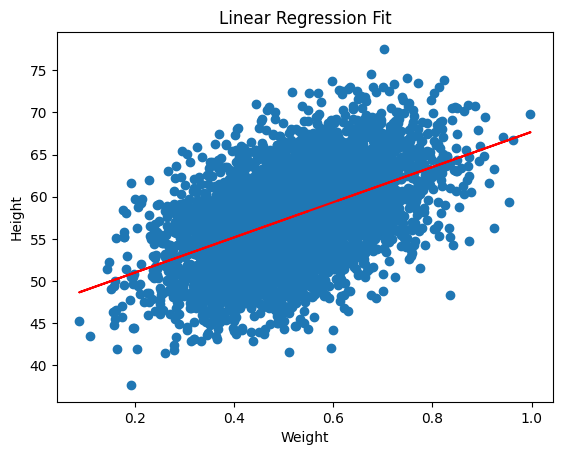

In [16]:
# 📈 Plot
plt.scatter(x_test, y_test)
plt.plot(x_test, y_pred, color='red')
plt.xlabel("Weight")
plt.ylabel("Height")
plt.title("Linear Regression Fit")
plt.show()

In [17]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## Results with Linear Regression ##
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Test data MSE:", mse)
print("Test Data RMSE:", rmse)
print("Test data R2 Score:", r2)

Test data MSE: 21.711382130474252
Test Data RMSE: 4.659547416914464
Test data R2 Score: 0.23769276319138044


In [18]:
## Apply Ridge Regression ##

ridge_model= Ridge()
ridge_model.fit(x_train, y_train)

# Predicted Value
y_pred_ridge = ridge_model.predict(x_test)

# Results with Ridge Regression
mse = mean_squared_error(y_test, y_pred_ridge)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_ridge)

print("Test data MSE:", mse)
print("Test Data RMSE:", rmse)
print("Test data R2 Score:", r2)

Test data MSE: 21.71081723167194
Test Data RMSE: 4.659486799173481
Test data R2 Score: 0.2377125973245775


In [19]:
## Apply Random Forest Regressor ##

rf_model= RandomForestRegressor()
rf_model.fit(x_train, y_train)

# Predicted Value
y_pred_rf = ridge_model.predict(x_test)

# Results with Ridge Regression
mse = mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_rf)

print("Test data MSE:", mse)
print("Test Data RMSE:", rmse)
print("Test data R2 Score:", r2)

Test data MSE: 21.71081723167194
Test Data RMSE: 4.659486799173481
Test data R2 Score: 0.2377125973245775


In [20]:
## Apply Decision Tree ##

dt_model= DecisionTreeRegressor()
dt_model.fit(x_train, y_train)

# Predicted Value
y_pred_dt = ridge_model.predict(x_test)

# Results with Ridge Regression
mse = mean_squared_error(y_test, y_pred_dt)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_dt)

print("Test data MSE:", mse)
print("Test Data RMSE:", rmse)
print("Test data R2 Score:", r2)

Test data MSE: 21.71081723167194
Test Data RMSE: 4.659486799173481
Test data R2 Score: 0.2377125973245775


In [21]:
# Height Value from User and Predicting weight value

x_user= float( input("Enter Height in Feet:"))
user_height = [[x_user]]
user_height_scaled = scaler.transform(user_height)


# Predict Weight of user
weight_pred = LR_model.predict(user_height_scaled)

# Final output
print("Predicted weight:", round(weight_pred[0], 2), 'Kg\n\n\n')

Enter Height in Feet:5.9
Predicted weight: 61.59 Kg





/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
